# Three-dimensional semi-synthetic analysis for β0, β1, β2, Euler characteristic, and ECT

This notebook implements a three-dimensional semi-synthetic benchmark for evaluating finite-superlevel topological causal estimands.


The benchmark uses real Wisconsin breast-cancer covariates, a hidden binary confounder `U`, an observed treatment assignment depending on both observed covariates and `U`, and 3D potential outcomes with known high-density topology:

- Control potential outcome: one solid 3D component, so β0=1, β1=0, β2=0.
- Treated potential outcome: a solid torus plus a hollow spherical shell, so β0=2, β1=1, β2=1.
- Target topological causal contrast at the reference superlevel: Δβ0=1, Δβ1=1, Δβ2=1, and Δχ=1.

Weak ignorability is violated by construction because `U` affects both treatment and potential-outcome sampling. The selected finite topological signature is designed to remain stable under the hidden density reweighting. Because both potential outcomes and the hidden variable are available in this semi-synthetic construction, this stability can be evaluated by comparing finite signatures marginally and conditional on `U`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from scipy.special import expit
from skimage.measure import euler_number

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

BASE = Path.cwd()
PROJECT_DIR = BASE.parent if BASE.name == "notebooks" else BASE
FIG_DIR = PROJECT_DIR / "figures"
TAB_DIR = PROJECT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
N = 9000
GRID = 48
SMOOTH = 1.7
REF_LEVEL = 0.06
LEVELS = np.array([0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15, 0.18])
MIN_COMPONENT_SIZE = 20
B_BOOT = 10
BOUNDS = (np.array([-3.35, -1.85, -1.35]), np.array([3.35, 1.85, 1.35]))

## 3D topology and transform helpers

For a 3D binary cubical superlevel set, β0 is the number of connected foreground components, β2 is the number of enclosed complement components, and β1 is recovered from Euler's identity χ=β0−β1+β2. The ECT implementation below is a finite directional version of the Euler characteristic transform.

In [2]:
def clean_components(binary, min_component_size=MIN_COMPONENT_SIZE):
    b = np.asarray(binary, dtype=bool)
    if b.sum() == 0 or min_component_size <= 1:
        return b
    labels, _ = ndi.label(b, ndi.generate_binary_structure(3, 1))
    counts = np.bincount(labels.ravel())
    keep = np.flatnonzero(counts >= min_component_size)
    return np.isin(labels, keep) & (labels > 0)


def betti_numbers_3d(binary, min_component_size=MIN_COMPONENT_SIZE):
    b = clean_components(binary, min_component_size)
    if b.sum() == 0:
        return {"beta0": 0, "beta1": 0, "beta2": 0, "euler": 0, "voxels": 0}

    foreground_structure = ndi.generate_binary_structure(3, 1)
    beta0 = int(ndi.label(b, foreground_structure)[1])

    padded = np.pad(b, 1, constant_values=False)
    complement = ~padded
    labels_bg, n_bg = ndi.label(complement, ndi.generate_binary_structure(3, 3))
    border = np.zeros_like(complement, dtype=bool)
    border[0, :, :] = border[-1, :, :] = True
    border[:, 0, :] = border[:, -1, :] = True
    border[:, :, 0] = border[:, :, -1] = True
    outside_labels = set(np.unique(labels_bg[border]))
    outside_labels.discard(0)
    beta2 = int(len(set(range(1, n_bg + 1)) - outside_labels))

    chi = int(euler_number(b, connectivity=1))
    beta1 = max(int(beta0 + beta2 - chi), 0)
    return {"beta0": beta0, "beta1": beta1, "beta2": beta2, "euler": chi, "voxels": int(b.sum())}


def density_volume(points, weights=None, grid=GRID, smooth=SMOOTH, bounds=BOUNDS):
    points = np.asarray(points, dtype=float)
    if weights is None:
        weights = np.ones(len(points), dtype=float)
    weights = np.asarray(weights, dtype=float)
    lo, hi = bounds
    H, _ = np.histogramdd(points, bins=grid, range=list(zip(lo, hi)), weights=weights)
    return ndi.gaussian_filter(H, sigma=smooth, mode="constant")


def summarize_volume(vol, levels=LEVELS, min_component_size=MIN_COMPONENT_SIZE):
    vmax = float(vol.max()) if vol.size else 0.0
    rows = []
    for level in levels:
        binary = vol >= level * vmax if vmax > 0 else np.zeros_like(vol, dtype=bool)
        row = betti_numbers_3d(binary, min_component_size)
        row["level"] = float(level)
        rows.append(row)
    return pd.DataFrame(rows)


def contrast_from_volumes(vol0, vol1, levels=LEVELS, ref_level=REF_LEVEL, min_component_size=MIN_COMPONENT_SIZE):
    s0 = summarize_volume(vol0, levels, min_component_size)
    s1 = summarize_volume(vol1, levels, min_component_size)
    rows = []
    for i, level in enumerate(levels):
        row = {"level": float(level)}
        for key in ["beta0", "beta1", "beta2", "euler"]:
            row[f"d_{key}"] = int(s1.loc[i, key] - s0.loc[i, key])
        rows.append(row)
    curve = pd.DataFrame(rows)
    ref = curve.iloc[(curve["level"] - ref_level).abs().argmin()].copy()
    return s0, s1, curve, ref


def make_directions():
    dirs = []
    for axis in np.eye(3):
        dirs.append(axis)
        dirs.append(-axis)
    for signs in [(-1, -1, -1), (-1, 1, 1), (1, -1, 1), (1, 1, -1), (1, 1, 1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1)]:
        v = np.asarray(signs, dtype=float)
        dirs.append(v / np.linalg.norm(v))
    return np.vstack(dirs)


def finite_ect(binary, directions=None, n_steps=6):
    b = np.asarray(binary, dtype=bool)
    if directions is None:
        directions = make_directions()
    coords = np.indices(b.shape).reshape(3, -1).T.astype(float)
    coords = coords / np.maximum(np.asarray(b.shape) - 1, 1)
    flat_b = b.ravel()
    values = []
    for direction in directions:
        projection = coords @ direction
        for threshold in np.linspace(projection.min(), projection.max(), n_steps):
            sublevel = (flat_b & (projection <= threshold)).reshape(b.shape)
            values.append(int(euler_number(sublevel, connectivity=1)) if sublevel.any() else 0)
    return np.asarray(values, dtype=float)


def ect_contrast(vol0, vol1, level=REF_LEVEL, directions=None, n_steps=6, min_component_size=MIN_COMPONENT_SIZE):
    b0 = clean_components(vol0 >= level * vol0.max(), min_component_size)
    b1 = clean_components(vol1 >= level * vol1.max(), min_component_size)
    return finite_ect(b1, directions, n_steps) - finite_ect(b0, directions, n_steps)


def check_topology_helpers():
    x = np.linspace(-1.5, 1.5, 56)
    X, Y, Z = np.meshgrid(x, x, x, indexing="ij")
    ball = X**2 + Y**2 + Z**2 <= 0.75**2
    shell = (X**2 + Y**2 + Z**2 >= 0.50**2) & (X**2 + Y**2 + Z**2 <= 0.85**2)
    torus = ((np.sqrt(X**2 + Y**2) - 0.70)**2 + Z**2) <= 0.18**2
    return pd.DataFrame({
        "solid_ball": betti_numbers_3d(ball, 1),
        "hollow_shell": betti_numbers_3d(shell, 1),
        "solid_torus": betti_numbers_3d(torus, 1),
    }).T

print("Sanity check of analytic 3D shapes:")
display(check_topology_helpers())

Sanity check of analytic 3D shapes:


,beta0,beta1,beta2,euler,voxels
solid_ball,1,0,0,1,11056
hollow_shell,1,0,1,2,12800
solid_torus,1,1,0,0,2728


## Data generator, treatment model, and conventional causal summaries

The observed covariates are real. The 3D potential outcomes are generated conditionally on those covariates and on hidden `U`. The same functions are reused for the noise and topological-complexity sensitivity checks.

In [3]:
def sample_ball(n, rng, U=None, z_score=None, noise=0.015, center=(0.0, 0.0, 0.0), radius=0.85):
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    rad = radius * rng.random(n) ** (1 / 3)
    pts = v * rad[:, None] + np.asarray(center)
    if U is not None:
        pts += (2 * U[:, None] - 1) * np.array([0.18, 0.0, 0.0])
    if z_score is not None:
        pts += z_score[:, None] * np.array([0.0, 0.06, -0.04])
    pts += rng.normal(scale=noise, size=(n, 3))
    return pts


def sample_shell(n, rng, U=None, z_score=None, noise=0.015, center=(1.9, 0.0, 0.0), inner=0.55, outer=0.90):
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    rad = (inner**3 + rng.random(n) * (outer**3 - inner**3)) ** (1 / 3)
    pts = v * rad[:, None] + np.asarray(center)
    if U is not None:
        pts += (2 * U[:, None] - 1) * np.array([0.08, 0.06, 0.0])
    if z_score is not None:
        pts += z_score[:, None] * np.array([0.0, 0.03, 0.02])
    pts += rng.normal(scale=noise, size=(n, 3))
    return pts


def sample_torus(n, rng, U=None, z_score=None, noise=0.015, center=(-1.9, 0.0, 0.0), R=0.75, r=0.20):
    theta = rng.uniform(0, 2 * np.pi, size=n)
    phi = rng.uniform(0, 2 * np.pi, size=n)
    tube_radius = r * np.sqrt(rng.random(n))
    x = (R + tube_radius * np.cos(phi)) * np.cos(theta)
    y = (R + tube_radius * np.cos(phi)) * np.sin(theta)
    z = tube_radius * np.sin(phi)
    pts = np.c_[x, y, z] + np.asarray(center)
    if U is not None:
        pts += (2 * U[:, None] - 1) * np.array([0.06, -0.04, 0.04])
    if z_score is not None:
        pts += z_score[:, None] * np.array([0.0, 0.02, -0.03])
    pts += rng.normal(scale=noise, size=(n, 3))
    return pts


def sample_y1(n, rng, U, z_score, noise=0.015, complexity="torus_shell"):
    if complexity == "two_components":
        p_right = expit(-0.25 + 0.60 * U + 0.10 * z_score)
        right = rng.binomial(1, p_right, size=n).astype(bool)
        pts = np.empty((n, 3))
        pts[~right] = sample_ball((~right).sum(), rng, U[~right], z_score[~right], noise=noise, center=(-1.25, 0, 0), radius=0.45)
        pts[right] = sample_ball(right.sum(), rng, U[right], z_score[right], noise=noise, center=(1.25, 0, 0), radius=0.45)
        return pts
    if complexity == "torus_only":
        return sample_torus(n, rng, U, z_score, noise=noise, center=(0.0, 0.0, 0.0), R=0.75, r=0.20)

    p_shell = np.where(U == 1, 0.62, 0.38)
    shell = rng.binomial(1, p_shell, size=n).astype(bool)
    pts = np.empty((n, 3))
    pts[~shell] = sample_torus((~shell).sum(), rng, U[~shell], z_score[~shell], noise=noise)
    pts[shell] = sample_shell(shell.sum(), rng, U[shell], z_score[shell], noise=noise)
    return pts


def make_semisynthetic_data(n=N, seed=SEED, noise=0.015, complexity="torus_shell"):
    rng = np.random.default_rng(seed)
    bc = load_breast_cancer()
    X = StandardScaler().fit_transform(bc.data)
    Z_all = PCA(n_components=8, random_state=seed).fit_transform(X)
    idx = rng.integers(0, Z_all.shape[0], size=n)
    Z = Z_all[idx]
    z1, z2 = Z[:, 0], Z[:, 1]
    U = rng.binomial(1, expit(-0.15 + 0.85 * z1))
    propensity_true = expit(-0.10 + 0.75 * z1 - 0.35 * z2 + 1.45 * (U - 0.5))
    propensity_true = np.clip(propensity_true, 0.03, 0.97)
    T = rng.binomial(1, propensity_true)
    Y0 = sample_ball(n, rng, U=U, z_score=z1, noise=noise)
    Y1 = sample_y1(n, rng, U=U, z_score=z1, noise=noise, complexity=complexity)
    Yobs = np.where(T[:, None] == 1, Y1, Y0)
    df = pd.DataFrame(Z, columns=[f"z{i}" for i in range(1, 9)])
    df["U"] = U
    df["T"] = T
    df["p_true"] = propensity_true
    df["norm0"] = np.linalg.norm(Y0, axis=1)
    df["norm1"] = np.linalg.norm(Y1, axis=1)
    df["norm_obs"] = np.where(T == 1, df["norm1"], df["norm0"])
    for j in range(3):
        df[f"Y{j+1}_obs"] = Yobs[:, j]
    return df, {"Y0": Y0, "Y1": Y1, "Yobs": Yobs}


def fit_propensity(df, include_U=False, clip=0.02):
    features = [f"z{i}" for i in range(1, 9)] + (["U"] if include_U else [])
    model = LogisticRegression(max_iter=2000, C=1.0)
    model.fit(df[features], df["T"])
    p = model.predict_proba(df[features])[:, 1]
    return np.clip(p, clip, 1 - clip)


def ipw_weights(T, p):
    T = np.asarray(T)
    return np.where(T == 1, 1 / p, 1 / (1 - p))


def overlap_weights(T, p):
    T = np.asarray(T)
    return np.where(T == 1, 1 - p, p)


def weighted_mean(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        return float(np.mean(x))
    w = np.asarray(w, dtype=float)
    return float(np.sum(w * x) / np.sum(w))


def smd(x, T, w=None):
    x = np.asarray(x, dtype=float)
    T = np.asarray(T).astype(bool)
    if w is None:
        m1, m0 = np.mean(x[T]), np.mean(x[~T])
        v1, v0 = np.var(x[T]), np.var(x[~T])
    else:
        w = np.asarray(w, dtype=float)
        m1 = weighted_mean(x[T], w[T])
        m0 = weighted_mean(x[~T], w[~T])
        v1 = weighted_mean((x[T] - m1) ** 2, w[T])
        v0 = weighted_mean((x[~T] - m0) ** 2, w[~T])
    denom = np.sqrt((v1 + v0) / 2)
    return float((m1 - m0) / denom) if denom > 1e-12 else 0.0


def balance_table(df, weights_by_name):
    covariates = [f"z{i}" for i in range(1, 9)] + ["U"]
    rows = []
    for cov in covariates:
        row = {"covariate": cov}
        for name, weights in weights_by_name.items():
            row[name] = smd(df[cov], df["T"], weights)
        rows.append(row)
    return pd.DataFrame(rows)


def scalar_ate_table(df, weights_by_name):
    T = df["T"].to_numpy().astype(bool)
    rows = [{
        "estimand": "oracle_potential_mean_norm",
        "estimate": df["norm1"].mean() - df["norm0"].mean(),
        "notes": "Uses both potential outcomes; available only in the semi-synthetic benchmark."
    }]
    for name, weights in weights_by_name.items():
        if weights is None:
            est = df.loc[T, "norm_obs"].mean() - df.loc[~T, "norm_obs"].mean()
        else:
            est = weighted_mean(df.loc[T, "norm_obs"], weights[T]) - weighted_mean(df.loc[~T, "norm_obs"], weights[~T])
        rows.append({"estimand": f"observed_{name}_mean_norm", "estimate": est, "notes": "Conventional scalar mean contrast of ||Y||."})
    return pd.DataFrame(rows)

## Main data, diagnostics, and ignorability checks

The hidden confounder is not used by the observed propensity score. The oracle propensity score is reported only to show how much of the violation can be repaired if the hidden variable were known.

In [4]:
df, arrays = make_semisynthetic_data()
df["p_hat_Z"] = fit_propensity(df, include_U=False)
df["p_hat_oracle"] = fit_propensity(df, include_U=True)
df["w_ipw_Z"] = ipw_weights(df["T"], df["p_hat_Z"])
df["w_overlap_Z"] = overlap_weights(df["T"], df["p_hat_Z"])
df["w_ipw_oracle"] = ipw_weights(df["T"], df["p_hat_oracle"])

weights_by_name = {
    "raw": None,
    "IPW_Z": df["w_ipw_Z"].to_numpy(),
    "overlap_Z": df["w_overlap_Z"].to_numpy(),
    "IPW_oracle_ZU": df["w_ipw_oracle"].to_numpy(),
}

design_summary = pd.DataFrame({
    "quantity": ["n", "treated_share", "P(T=1|U=1)", "P(T=1|U=0)", "mean_true_p", "min_hat_p_Z", "max_hat_p_Z"],
    "value": [len(df), df["T"].mean(), df.loc[df.U == 1, "T"].mean(), df.loc[df.U == 0, "T"].mean(), df.p_true.mean(), df.p_hat_Z.min(), df.p_hat_Z.max()]
})
print("Design summary")
display(design_summary)

bal = balance_table(df, weights_by_name)
print("Standardized mean differences. U is hidden from the observed adjustment set, so residual imbalance in U diagnoses weak-ignorability failure.")
display(bal)
bal.to_csv(TAB_DIR / "3d_semisynthetic_balance.csv", index=False)

weak_rows = []
T_bool = df["T"].to_numpy().astype(bool)
for ycol in ["norm0", "norm1"]:
    weak_rows.append({
        "potential_outcome_summary": ycol,
        "raw_difference_T1_minus_T0": df.loc[T_bool, ycol].mean() - df.loc[~T_bool, ycol].mean(),
        "IPW_Z_difference": weighted_mean(df.loc[T_bool, ycol], df.loc[T_bool, "w_ipw_Z"]) - weighted_mean(df.loc[~T_bool, ycol], df.loc[~T_bool, "w_ipw_Z"]),
        "IPW_oracle_ZU_difference": weighted_mean(df.loc[T_bool, ycol], df.loc[T_bool, "w_ipw_oracle"]) - weighted_mean(df.loc[~T_bool, ycol], df.loc[~T_bool, "w_ipw_oracle"]),
    })
weak_table = pd.DataFrame(weak_rows)
print("Direct semi-synthetic weak-ignorability check using observed and counterfactual potential-outcome summaries")
display(weak_table)
weak_table.to_csv(TAB_DIR / "3d_semisynthetic_weak_ignorability.csv", index=False)

print("Conventional scalar causal estimands")
scalar_table = scalar_ate_table(df, weights_by_name)
display(scalar_table)
scalar_table.to_csv(TAB_DIR / "3d_semisynthetic_conventional_estimands.csv", index=False)

Design summary


,quantity,value
0,n,9000.000000
1,treated_share,0.406222
2,P(T=1|U=1),0.802515
3,P(T=1|U=0),0.124834
4,mean_true_p,0.405270
5,min_hat_p_Z,0.020000
6,max_hat_p_Z,0.980000


Standardized mean differences. U is hidden from the observed adjustment set, so residual imbalance in U diagnoses weak-ignorability failure.


,covariate,raw,IPW_Z,overlap_Z,IPW_oracle_ZU
0,z1,1.931449,-0.006796,0.062448,0.017257
1,z2,-0.193162,-0.035197,-0.014648,-0.017849
2,z3,-0.155162,0.010365,0.005741,-0.003977
3,z4,0.105256,-0.015494,-0.004675,-0.022686
4,z5,-0.040866,0.032442,0.004029,0.012410
5,z6,0.009463,-0.006278,-0.000157,0.016204
6,z7,-0.157905,-0.014296,0.009474,-0.004475
7,z8,0.030811,0.021615,0.000111,0.027439
8,U,1.869073,0.335846,0.526900,0.025790


Direct semi-synthetic weak-ignorability check using observed and counterfactual potential-outcome summaries


,potential_outcome_summary,raw_difference_T1_minus_T0,IPW_Z_difference,IPW_oracle_ZU_difference
0,norm0,0.041358,0.005156,0.002675
1,norm1,0.014158,-0.023310,-0.025027


Conventional scalar causal estimands


,estimand,estimate,notes
0,oracle_potential_mean_norm,1.318485,Uses both potential outcomes; available only i...
1,observed_raw_mean_norm,1.343693,Conventional scalar mean contrast of ||Y||.
2,observed_IPW_Z_mean_norm,1.281010,Conventional scalar mean contrast of ||Y||.
3,observed_overlap_Z_mean_norm,1.316691,Conventional scalar mean contrast of ||Y||.
4,observed_IPW_oracle_ZU_mean_norm,1.282996,Conventional scalar mean contrast of ||Y||.


## Main 3D topological causal estimands

The table reports the reference-superlevel topological contrasts. The full Betti and Euler curves across superlevels are plotted afterward.

Reference-level 3D topological contrasts


,method,level,d_beta0,d_beta1,d_beta2,d_euler
0,oracle_potential,0.06,1.0,1.0,1.0,1.0
1,observed_raw,0.06,1.0,1.0,1.0,1.0
2,observed_IPW_Z,0.06,1.0,0.0,1.0,2.0
3,observed_overlap_Z,0.06,1.0,1.0,1.0,1.0
4,observed_IPW_oracle_ZU,0.06,1.0,1.0,1.0,1.0


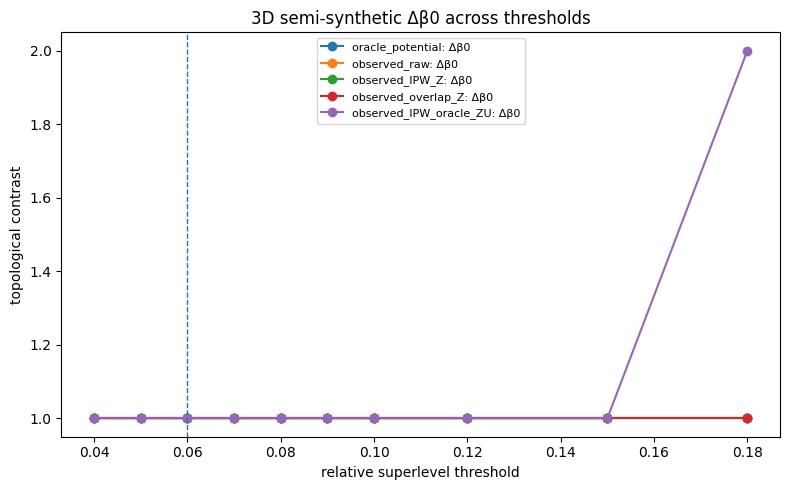

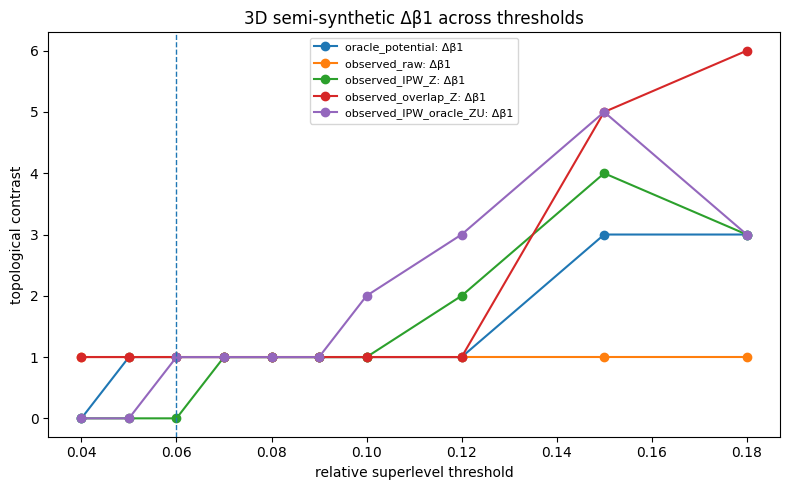

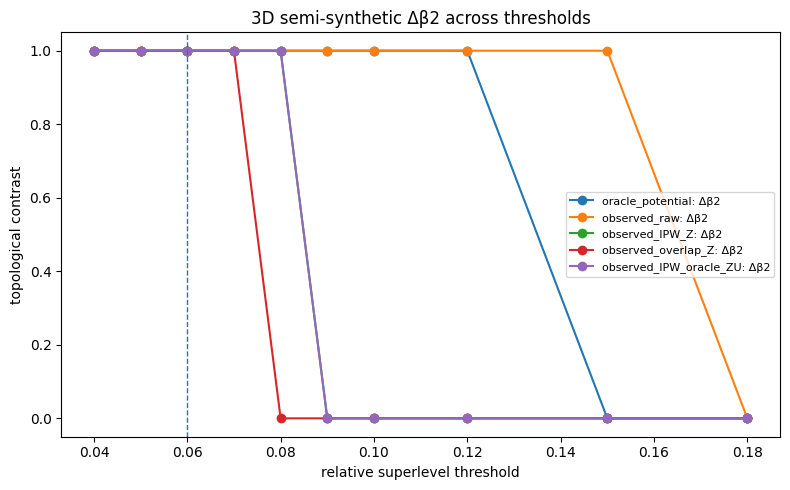

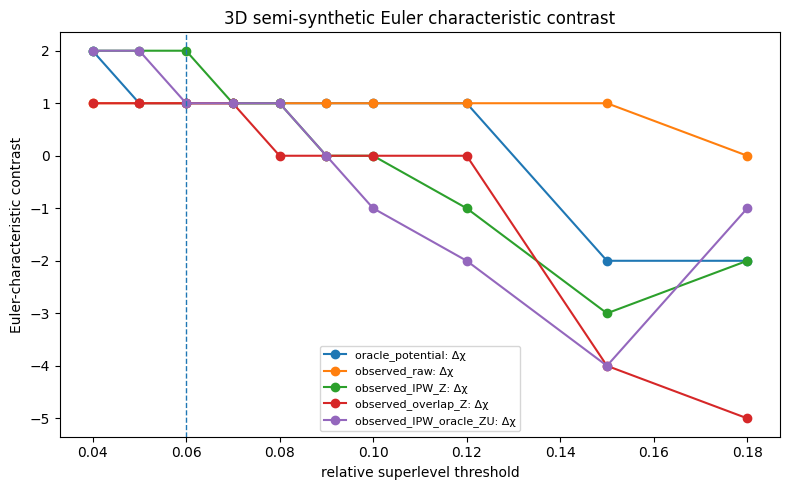

In [5]:
def estimate_topological_methods(df, arrays, levels=LEVELS, ref_level=REF_LEVEL, min_component_size=MIN_COMPONENT_SIZE, bounds=BOUNDS):
    T = df["T"].to_numpy().astype(bool)
    Y0, Y1, Yobs = arrays["Y0"], arrays["Y1"], arrays["Yobs"]
    method_specs = {
        "oracle_potential": (Y0, None, Y1, None),
        "observed_raw": (Yobs[~T], None, Yobs[T], None),
        "observed_IPW_Z": (Yobs[~T], df.loc[~T, "w_ipw_Z"].to_numpy(), Yobs[T], df.loc[T, "w_ipw_Z"].to_numpy()),
        "observed_overlap_Z": (Yobs[~T], df.loc[~T, "w_overlap_Z"].to_numpy(), Yobs[T], df.loc[T, "w_overlap_Z"].to_numpy()),
        "observed_IPW_oracle_ZU": (Yobs[~T], df.loc[~T, "w_ipw_oracle"].to_numpy(), Yobs[T], df.loc[T, "w_ipw_oracle"].to_numpy()),
    }
    results = {}
    ref_rows = []
    for name, (pts0, w0, pts1, w1) in method_specs.items():
        vol0 = density_volume(pts0, w0, bounds=bounds)
        vol1 = density_volume(pts1, w1, bounds=bounds)
        s0, s1, curve, ref = contrast_from_volumes(vol0, vol1, levels, ref_level, min_component_size)
        results[name] = {"vol0": vol0, "vol1": vol1, "s0": s0, "s1": s1, "curve": curve, "ref": ref}
        ref_rows.append({"method": name, **ref.to_dict()})
    return results, pd.DataFrame(ref_rows)

main_results, ref_table = estimate_topological_methods(df, arrays)
print("Reference-level 3D topological contrasts")
display(ref_table[["method", "level", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
ref_table.to_csv(TAB_DIR / "3d_semisynthetic_topological_reference.csv", index=False)

curve_long = []
for method, obj in main_results.items():
    c = obj["curve"].copy()
    c["method"] = method
    curve_long.append(c)
curve_long = pd.concat(curve_long, ignore_index=True)
curve_long.to_csv(TAB_DIR / "3d_semisynthetic_betti_curves.csv", index=False)

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["level"], obj["curve"]["d_beta0"], marker="o", label=f"{method}: Δβ0")
plt.axvline(REF_LEVEL, linestyle="--", linewidth=1)
plt.xlabel("relative superlevel threshold")
plt.ylabel("topological contrast")
plt.title("3D semi-synthetic Δβ0 across thresholds")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_delta_beta0.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["level"], obj["curve"]["d_beta1"], marker="o", label=f"{method}: Δβ1")
plt.axvline(REF_LEVEL, linestyle="--", linewidth=1)
plt.xlabel("relative superlevel threshold")
plt.ylabel("topological contrast")
plt.title("3D semi-synthetic Δβ1 across thresholds")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_delta_beta1.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["level"], obj["curve"]["d_beta2"], marker="o", label=f"{method}: Δβ2")
plt.axvline(REF_LEVEL, linestyle="--", linewidth=1)
plt.xlabel("relative superlevel threshold")
plt.ylabel("topological contrast")
plt.title("3D semi-synthetic Δβ2 across thresholds")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_delta_beta2.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["level"], obj["curve"]["d_euler"], marker="o", label=f"{method}: Δχ")
plt.axvline(REF_LEVEL, linestyle="--", linewidth=1)
plt.xlabel("relative superlevel threshold")
plt.ylabel("Euler-characteristic contrast")
plt.title("3D semi-synthetic Euler characteristic contrast")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_delta_euler.png", dpi=180)
plt.show()

## Conditional topological ignorability check

The next table compares finite signatures of the potential-outcome distributions marginally and conditional on the hidden confounder. This is stronger than a usual observational diagnostic because the semi-synthetic construction exposes both potential outcomes and the hidden variable.

In [6]:
def signature_for_points(points, label, weights=None, levels=np.array([REF_LEVEL]), bounds=BOUNDS):
    vol = density_volume(points, weights=weights, bounds=bounds)
    sig = summarize_volume(vol, levels=levels).iloc[0].to_dict()
    sig["subset"] = label
    return sig

cti_rows = []
for tname, arr_name in [("Y0", "Y0"), ("Y1", "Y1")]:
    cti_rows.append(signature_for_points(arrays[arr_name], f"{tname}_marginal"))
    for u in [0, 1]:
        mask = df["U"].to_numpy() == u
        cti_rows.append(signature_for_points(arrays[arr_name][mask], f"{tname}_given_U={u}"))
cti_table = pd.DataFrame(cti_rows)[["subset", "level", "beta0", "beta1", "beta2", "euler", "voxels"]]
print("Topological ignorability diagnostic: finite signatures are stable after conditioning on hidden U at the reference level.")
display(cti_table)
cti_table.to_csv(TAB_DIR / "3d_semisynthetic_topological_ignorability_hiddenU.csv", index=False)

Topological ignorability diagnostic: finite signatures are stable after conditioning on hidden U at the reference level.


,subset,level,beta0,beta1,beta2,euler,voxels
0,Y0_marginal,0.06,1.0,0.0,0.0,1.0,10632.0
1,Y0_given_U=0,0.06,1.0,0.0,0.0,1.0,8749.0
2,Y0_given_U=1,0.06,1.0,0.0,0.0,1.0,9671.0
3,Y1_marginal,0.06,2.0,1.0,1.0,2.0,11962.0
4,Y1_given_U=0,0.06,2.0,1.0,1.0,2.0,9610.0
5,Y1_given_U=1,0.06,2.0,1.0,1.0,2.0,13354.0


## Euler Characteristic Transform summaries

ECTs are evaluated at 14 directions and 10 slicing thresholds per direction. The table compares the observed estimators to the oracle potential-outcome ECT contrast.

In [7]:
directions = make_directions()
oracle_ect = ect_contrast(main_results["oracle_potential"]["vol0"], main_results["oracle_potential"]["vol1"], directions=directions)
ect_rows = []
for method, obj in main_results.items():
    vec = ect_contrast(obj["vol0"], obj["vol1"], directions=directions)
    denom = np.linalg.norm(vec) * np.linalg.norm(oracle_ect)
    cosine = float(np.dot(vec, oracle_ect) / denom) if denom > 0 else np.nan
    ect_rows.append({
        "method": method,
        "ECT_L2_norm": float(np.linalg.norm(vec)),
        "ECT_mean": float(vec.mean()),
        "ECT_max_abs": float(np.max(np.abs(vec))),
        "cosine_to_oracle": cosine,
        "L2_distance_to_oracle": float(np.linalg.norm(vec - oracle_ect)),
    })
ect_table = pd.DataFrame(ect_rows)
print("Finite ECT contrast summaries")
display(ect_table)
ect_table.to_csv(TAB_DIR / "3d_semisynthetic_ect_summary.csv", index=False)

Finite ECT contrast summaries


,method,ECT_L2_norm,ECT_mean,ECT_max_abs,cosine_to_oracle,L2_distance_to_oracle
0,oracle_potential,11.313708,0.452381,6.0,1.000000,0.000000
1,observed_raw,14.525839,0.583333,6.0,0.407689,14.317821
2,observed_IPW_Z,14.000000,1.071429,5.0,0.441942,13.564660
3,observed_overlap_Z,9.949874,0.535714,3.0,0.737319,7.810250
4,observed_IPW_oracle_ZU,14.594520,0.797619,9.0,0.272532,15.842980


## Sensitivity analyses: odds tilts, bootstrap, noise, and topological complexity

The odds-tilt analysis uses the hidden variable only as an oracle stress test: if an unmeasured factor changed the observed IPW weights in this direction, would the topological conclusion change? The bootstrap gives finite-sample stability of the IPW estimator. The complexity/noise grid checks whether β2 remains detectable when the topology and point-cloud noise change.

Hidden-U odds-tilt sensitivity of observed IPW topological contrast


,gamma_hidden_U_tilt,d_beta0,d_beta1,d_beta2,d_euler
0,-2.0,1.0,4.0,0.0,-3.0
1,-1.0,1.0,2.0,0.0,-1.0
2,-0.5,1.0,1.0,1.0,1.0
3,0.0,1.0,0.0,1.0,2.0
4,0.5,1.0,1.0,1.0,1.0
5,1.0,1.0,1.0,1.0,1.0
6,2.0,1.0,1.0,1.0,1.0


Bootstrap distribution for observed IPW topological contrasts


,d_beta0,d_beta1,d_beta2,d_euler
count,10.0,10.000000,10.000000,10.000000
mean,1.0,0.800000,0.900000,1.100000
std,0.0,0.421637,0.316228,0.567646
min,1.0,0.000000,0.000000,0.000000
25%,1.0,1.000000,1.000000,1.000000
50%,1.0,1.000000,1.000000,1.000000
75%,1.0,1.000000,1.000000,1.000000
max,1.0,1.000000,1.000000,2.000000


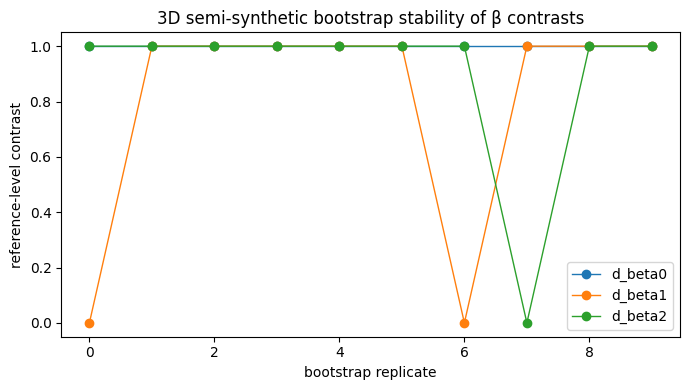

Oracle topological complexity and noise sensitivity


,complexity,noise_sd,d_beta0,d_beta1,d_beta2,d_euler
0,two_components,0.005,1.0,0.0,0.0,1.0
1,two_components,0.020,1.0,0.0,0.0,1.0
2,two_components,0.060,1.0,0.0,0.0,1.0
3,torus_only,0.005,0.0,1.0,0.0,-1.0
4,torus_only,0.020,0.0,1.0,0.0,-1.0
5,torus_only,0.060,0.0,1.0,0.0,-1.0
6,torus_shell,0.005,1.0,1.0,1.0,1.0
7,torus_shell,0.020,1.0,1.0,1.0,1.0
8,torus_shell,0.060,1.0,1.0,1.0,1.0


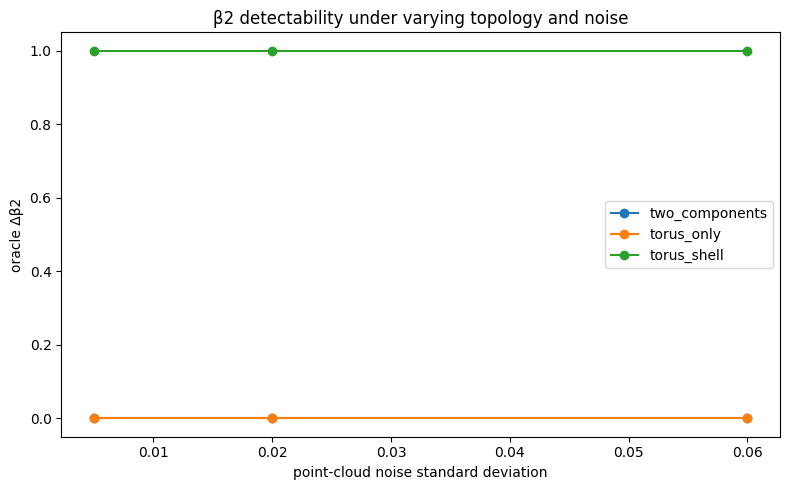

In [8]:
def topological_ref_for_observed(df, arrays, group_weights=None, levels=LEVELS):
    T = df["T"].to_numpy().astype(bool)
    Yobs = arrays["Yobs"]
    if group_weights is None:
        w = None
        vol0 = density_volume(Yobs[~T], None)
        vol1 = density_volume(Yobs[T], None)
    else:
        w = np.asarray(group_weights)
        vol0 = density_volume(Yobs[~T], w[~T])
        vol1 = density_volume(Yobs[T], w[T])
    return contrast_from_volumes(vol0, vol1)[3]

# Odds-tilt sensitivity around the observed IPW estimator.
tilt_rows = []
for gamma in [-2, -1, -0.5, 0, 0.5, 1, 2]:
    tilt = np.exp(gamma * (df["U"].to_numpy() - df["U"].mean()))
    w = df["w_ipw_Z"].to_numpy() * tilt
    ref = topological_ref_for_observed(df, arrays, w)
    tilt_rows.append({"gamma_hidden_U_tilt": gamma, **ref.to_dict()})
tilt_table = pd.DataFrame(tilt_rows)
print("Hidden-U odds-tilt sensitivity of observed IPW topological contrast")
display(tilt_table[["gamma_hidden_U_tilt", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
tilt_table.to_csv(TAB_DIR / "3d_semisynthetic_odds_tilt.csv", index=False)

# Bootstrap stability of the observed IPW estimator.
rng = np.random.default_rng(SEED + 44)
boot_rows = []
idx_all = np.arange(len(df))
for b in range(B_BOOT):
    idx = rng.choice(idx_all, size=len(idx_all), replace=True)
    df_b = df.iloc[idx].reset_index(drop=True)
    arrays_b = {"Yobs": arrays["Yobs"][idx]}
    ref = topological_ref_for_observed(df_b, arrays_b, df_b["w_ipw_Z"].to_numpy())
    boot_rows.append({"bootstrap": b, **ref.to_dict()})
boot = pd.DataFrame(boot_rows)
print("Bootstrap distribution for observed IPW topological contrasts")
display(boot[["d_beta0", "d_beta1", "d_beta2", "d_euler"]].describe())
boot.to_csv(TAB_DIR / "3d_semisynthetic_bootstrap_ipw.csv", index=False)

plt.figure(figsize=(7, 4))
for col in ["d_beta0", "d_beta1", "d_beta2"]:
    plt.plot(boot["bootstrap"], boot[col], marker="o", linewidth=1, label=col)
plt.xlabel("bootstrap replicate")
plt.ylabel("reference-level contrast")
plt.title("3D semi-synthetic bootstrap stability of β contrasts")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_bootstrap_beta_contrasts.png", dpi=180)
plt.show()

# Noise and topological complexity sensitivity using the oracle potential-outcome distributions.
complexity_rows = []
for complexity in ["two_components", "torus_only", "torus_shell"]:
    for noise in [0.005, 0.020, 0.060]:
        df_s, arr_s = make_semisynthetic_data(n=3000, seed=SEED + int(noise * 1000) + len(complexity), noise=noise, complexity=complexity)
        vol0 = density_volume(arr_s["Y0"], None)
        vol1 = density_volume(arr_s["Y1"], None)
        ref = contrast_from_volumes(vol0, vol1)[3]
        complexity_rows.append({"complexity": complexity, "noise_sd": noise, **ref.to_dict()})
complexity_table = pd.DataFrame(complexity_rows)
print("Oracle topological complexity and noise sensitivity")
display(complexity_table[["complexity", "noise_sd", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
complexity_table.to_csv(TAB_DIR / "3d_semisynthetic_complexity_noise.csv", index=False)

plt.figure(figsize=(8, 5))
for complexity in complexity_table["complexity"].unique():
    sub = complexity_table[complexity_table["complexity"] == complexity]
    plt.plot(sub["noise_sd"], sub["d_beta2"], marker="o", label=complexity)
plt.xlabel("point-cloud noise standard deviation")
plt.ylabel("oracle Δβ2")
plt.title("β2 detectability under varying topology and noise")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_semisynthetic_noise_complexity_beta2.png", dpi=180)
plt.show()

## Interpretation

The oracle reference contrast is defined as Δβ0=1, Δβ1=1, Δβ2=1, and Δχ=1. Raw, observed-covariate IPW, overlap-weighted, and oracle-adjusted estimates are compared with this target. Conventional scalar mean contrasts provide familiar summaries but do not encode the creation of a loop or a void. The weak-ignorability diagnostics assess residual imbalance when adjustment uses only observed Z, while the hidden-U signature comparison evaluates stability of the selected finite topology across latent strata.